In [8]:
# Core
import re
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from adjustText import adjust_text
import seaborn as sns

# Load Dataset
df = pd.read_csv("D:/Data Analyst/project/Python_project_2/dataset/netflix_titles.csv")

# Parse date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year.astype('Int64')
df['month_added'] = df['date_added'].dt.month.astype('Int64')
df['month_name'] = df['date_added'].dt.strftime('%b')

# Extract duration values
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype('Int64')
df['duration_unit'] = df['duration'].str.extract(r'([a-zA-Z])')

# Fill missing ratings with 'Unknown'
df['rating'] = df['rating'].fillna("Unknown")

# Primary country (some entries have multiple countries)
df['primary_country'] = df['country'].str.split(',').str[0].str.strip()

In [9]:
df_explode = df['listed_in'].str.split(', ').explode()
genre_counts = df_explode.value_counts().head(20).to_frame() 

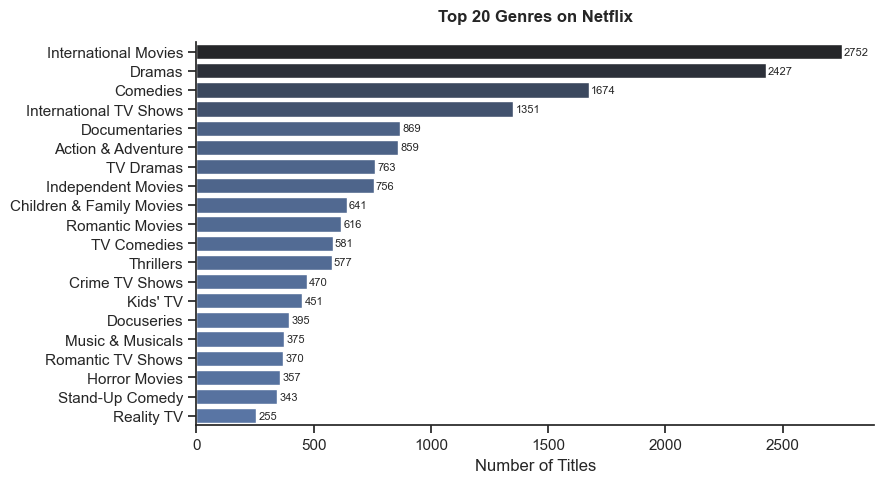

In [10]:
plt.figure(figsize=(9, 5))

sns.set_theme(style='ticks')
sns.barplot(
    data=genre_counts, 
    x='count', 
    y='listed_in',
    hue='count',
    palette='dark:b_r',
    legend=False
)
sns.despine()

plt.title('Top 20 Genres on Netflix', fontweight='bold', pad=15)
plt.xlabel('Number of Titles')
plt.ylabel('')

for i, value in enumerate(genre_counts['count']):
    plt.text(value+10, i, f'{value}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [11]:
movie_genre = df[df['type'] == 'Movie']['listed_in'].str.split(', ').explode()
tvshow_genre = df[df['type'] == 'TV Show']['listed_in'].str.split(', ').explode()

movie_top = movie_genre.value_counts().head(10).to_frame()
tvshow_top = tvshow_genre.value_counts().head(10).to_frame()


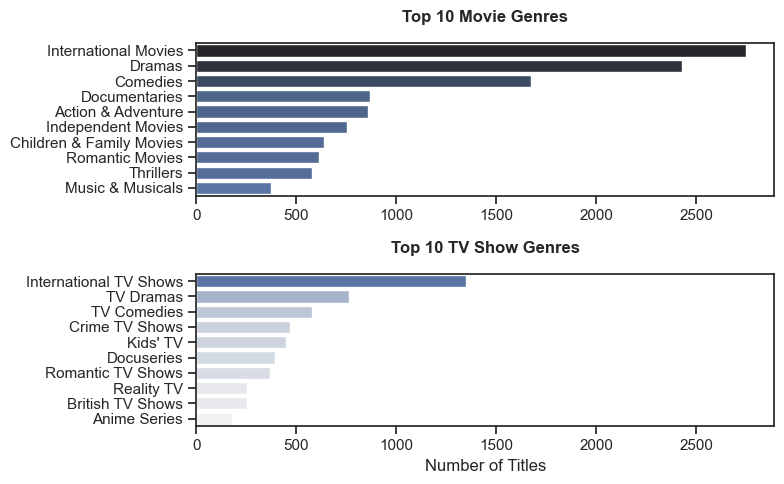

In [12]:
fig, ax = plt.subplots(2, 1, figsize=(8,5))

sns.set_theme(style='ticks')

# Top 10 Movie Genres
sns.barplot(data=movie_top, x='count', y='listed_in', ax=ax[0], hue='count', palette='dark:b_r')
ax[0].legend().remove()
ax[0].set_title('Top 10 Movie Genres', fontweight='bold', pad=15)
ax[0].set_ylabel('')
ax[0].set_xlabel('')

# Top 10 TV Show Genres
sns.barplot(data=tvshow_top, x='count', y='listed_in', ax=ax[1], hue='count', palette='light:b')
ax[1].legend().remove()
ax[1].set_title('Top 10 TV Show Genres', fontweight='bold', pad=15)
ax[1].set_ylabel('')
ax[1].set_xlabel('Number of Titles')
ax[1].set_xlim(ax[0].get_xlim())

plt.tight_layout()
plt.show()